Phase 1: Data Loading & First Look

In [ ]:
import pandas as pd 
import numpy as np 
import matplotlib.pyplot as plt 
import seaborn as sns

rw_df = pd.read_csv('River water_quality_2023.csv')

print(rw_df.dtypes)


Station_Code                int64
Location                      str
State                         str
Temp_Min                  float64
Temp_Max                  float64
DO_Min                        str
DO_Max                    float64
pH_Min                    float64
pH_Max                    float64
Conductivity_Min          float64
Conductivity_Max          float64
BOD_Min                       str
BOD_Max                   float64
Nitrate_Min               float64
Nitrate_Max               float64
Fecal_Coliform_Min            str
Fecal_Coliform_Max        float64
Total_Coliform_Min        float64
Total_Coliform_Max        float64
Fecal_Streptococci_Min        str
Fecal_Streptococci_Max        str
dtype: object


In [77]:
# Drop junk rows where Location is NaN
rw_df = rw_df.dropna(subset=['Location']).reset_index(drop=True)

# Clean State column
rw_df['State'] = rw_df['State'].str.replace('\n', ' ')

# Drop Fecal Streptococci columns
rw_df = rw_df.drop(columns=['Fecal_Streptococci_Min', 'Fecal_Streptococci_Max'])

# Convert to numeric
numeric_cols = rw_df.columns[3:]
rw_df[numeric_cols] = rw_df[numeric_cols].apply(pd.to_numeric, errors='coerce')

# Drop rows where State is NaN
rw_df = rw_df.dropna(subset=['State'])

# Check shape
print(rw_df.shape)
print(rw_df.isnull().sum())


(1519, 19)
Station_Code            0
Location                0
State                   0
Temp_Min               35
Temp_Max               35
DO_Min                  1
DO_Max                  1
pH_Min                  0
pH_Max                  0
Conductivity_Min       55
Conductivity_Max       55
BOD_Min                 0
BOD_Max                 0
Nitrate_Min             0
Nitrate_Max             0
Fecal_Coliform_Min    176
Fecal_Coliform_Max    176
Total_Coliform_Min    165
Total_Coliform_Max    165
dtype: int64


Phase 3: Exploration

In [ ]:
#check the column state
print(rw_df['State'].nunique())

#checking how many monitoring stations per state
print(rw_df.groupby('State')['Location'].count().sort_values(ascending=False))

print(rw_df.describe())


30
State
MADHYA PRADESH       155
HIMACHAL PRADESH     141
ODISHA               117
UTTAR PRADESH        109
KARNATAKA            106
MAHARASHTRA          104
BIHAR                 91
ASSAM                 66
JHARKHAND             61
WEST BENGAL           55
TAMIL NADU            53
JAMMU & KASHMIR       49
TELANGANA             49
PUNJAB                44
MIZORAM               39
UTTARAKHAND           37
GUJARAT               37
MEGHALAYA             37
SIKKIM                28
RAJASTHAN             26
ANDHRA PRADESH        23
CHHATTISGARH          22
NAGALAND              17
HARYANA               12
MANIPUR               11
ARUNACHAL PRADESH     10
DELHI                  9
KERALA                 5
TRIPURA                5
PUDUCHERRY             1
Name: Location, dtype: int64
       Station_Code     Temp_Min     Temp_Max       DO_Min       DO_Max  \
count   1519.000000  1484.000000  1484.000000  1518.000000  1518.000000   
mean    4591.050033    18.348450    27.647709     5.784124    

Phase 4: Visualisation

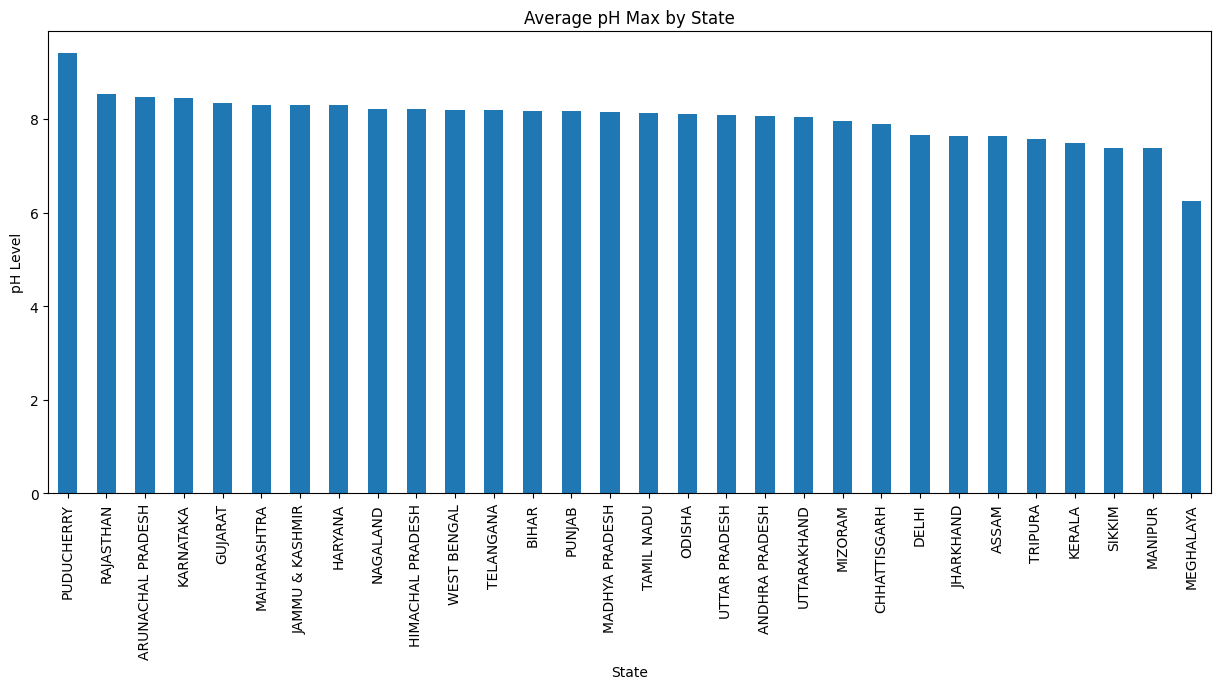

In [79]:
#Average pH_Min per state — bar chart
plt.figure(figsize=(15, 6))
rw_df.groupby('State')['pH_Max'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Average pH Max by State')                      
plt.xlabel('State')                     
plt.ylabel('pH Level')
plt.xticks(rotation=90 )
plt.show()

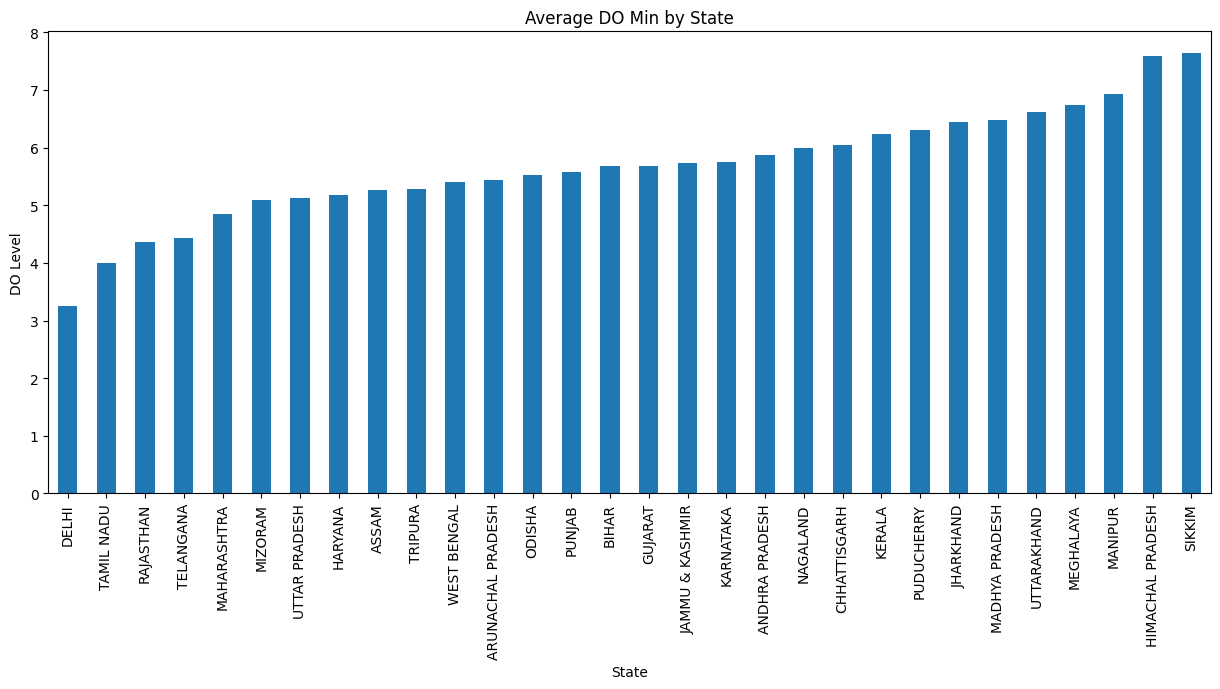

In [80]:
#Average DO_Min per state — bar chart 
plt.figure(figsize=(15, 6))
rw_df.groupby('State')['DO_Min'].mean().sort_values(ascending=True).plot(kind='bar')
plt.title('Average DO Min by State')                      
plt.xlabel('State')                     
plt.ylabel('DO Level')
plt.xticks(rotation=90 )
plt.show()

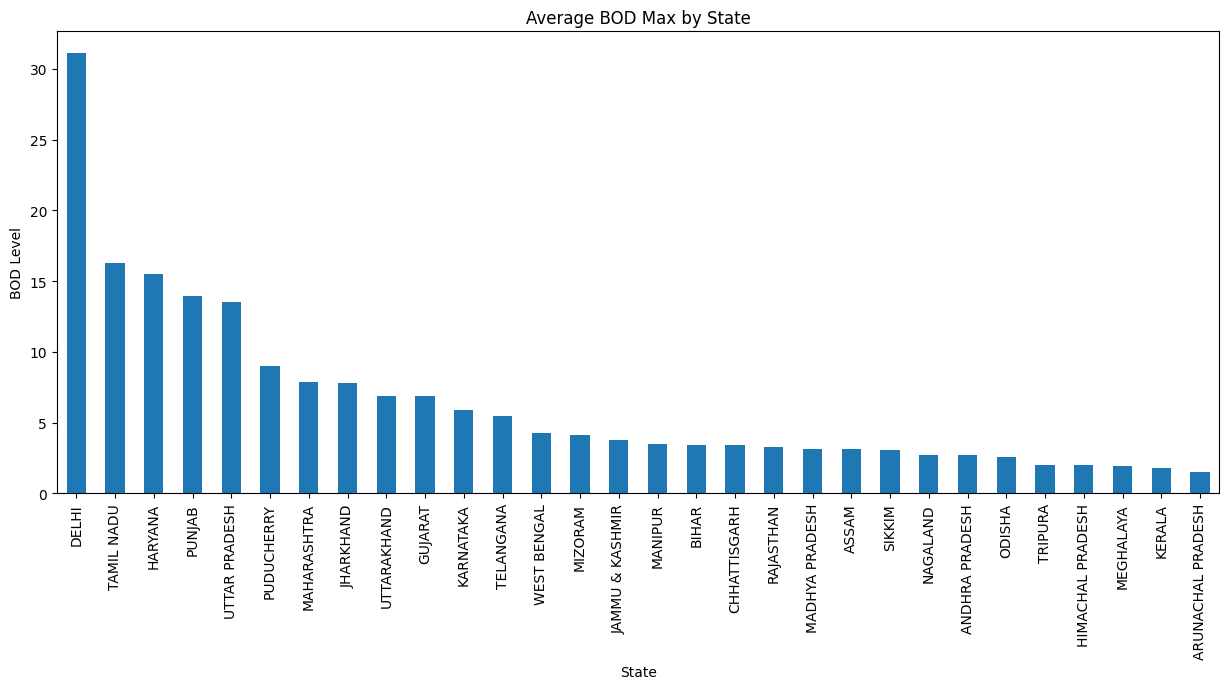

In [ ]:
# Average BOD_Max per state — bar chart
plt.figure(figsize=(15, 6))
rw_df.groupby('State')['BOD_Max'].mean().sort_values(ascending=False).plot(kind='bar')
plt.title('Average BOD Max by State')                      
plt.xlabel('State')                     
plt.ylabel('BOD Level')
plt.xticks(rotation=90 )
plt.show()

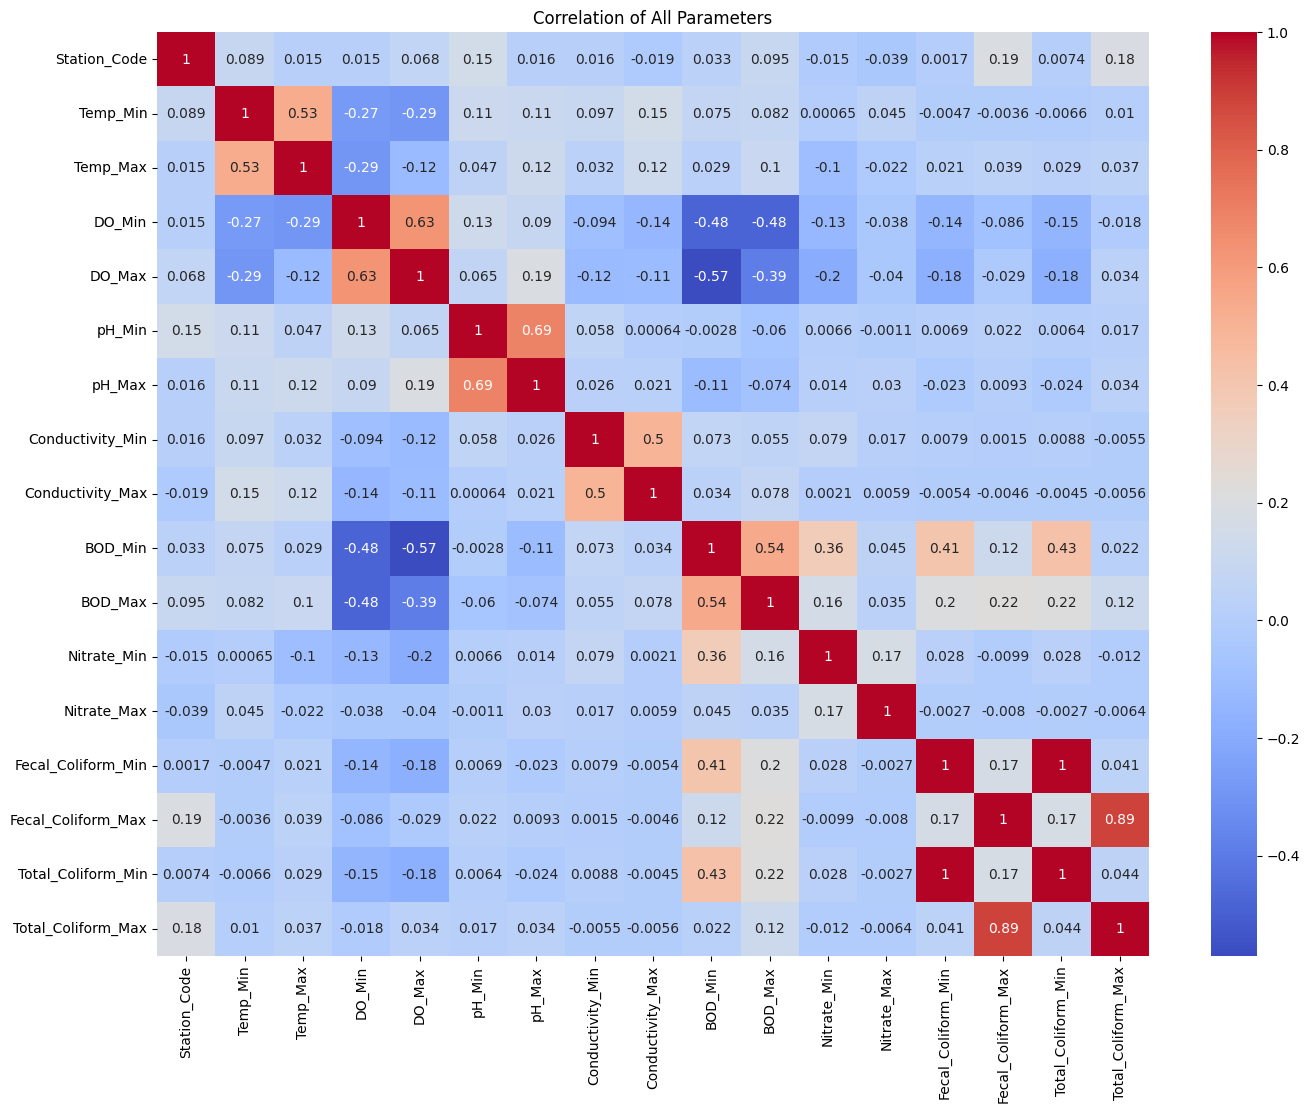

In [82]:
#Correlation heatmap of all parameters
plt.figure(figsize=(16, 12))
sns.heatmap(rw_df.select_dtypes(include='number').corr(), annot=True, cmap='coolwarm')
plt.title('Correlation of All Parameters')
plt.show()

Phase 5: Anomaly Detection

In [85]:
#Flag stations where pH_Min is below 6.5 OR pH_Max is above 8.5
rw_df['pH_anomaly'] =(rw_df['pH_Max'] > 8.5) | (rw_df['pH_Min']< 6.5 )

#DO Min Anomaly
rw_df['DO_anomaly'] = rw_df['DO_Min'] < 5

#BOD Max
rw_df['BOD_anomaly'] =rw_df['BOD_Max'] > 3

# Count total anomalies
print(rw_df['pH_anomaly'].sum())
print(rw_df['DO_anomaly'].sum())
print(rw_df['BOD_anomaly'].sum())

# Count anomalies per state
print(rw_df.groupby('State')['BOD_anomaly'].sum().sort_values(ascending=False))

# Top 10 most polluted stations
print(rw_df[rw_df['BOD_anomaly']==True].groupby('Location')['BOD_anomaly'].count().sort_values(ascending=False).head(10))

208
315
520
State
MAHARASHTRA          96
UTTAR PRADESH        85
KARNATAKA            60
TELANGANA            36
MADHYA PRADESH       22
JAMMU & KASHMIR      21
WEST BENGAL          20
TAMIL NADU           20
JHARKHAND            19
BIHAR                18
HIMACHAL PRADESH     18
ODISHA               13
UTTARAKHAND          13
HARYANA              12
PUNJAB               12
MANIPUR              11
DELHI                 8
RAJASTHAN             8
CHHATTISGARH          7
GUJARAT               6
MIZORAM               6
ASSAM                 3
NAGALAND              3
SIKKIM                1
ANDHRA PRADESH        1
PUDUCHERRY            1
KERALA                0
ARUNACHAL PRADESH     0
MEGHALAYA             0
TRIPURA               0
Name: BOD_anomaly, dtype: int64
Location
RIVER RAMGANGA AT ROAD BRIDGE SHERKOT,\nDIST.BIJNAUR (U.P.)         2
RIVER YAMUNA AT OKHLA BRIDGE (INLET OF AGRA\nCANAL), DELHI          1
RIVER YAMUNA AT OKHLA AFTER MEETING OF\nSHAHDARA DRAIN, DELHI       1
RIVER ADYAR

In [84]:
print(rw_df['DO_Min'].describe())
print(rw_df['DO_Min'].head(20))

count    1518.000000
mean        5.784124
std         1.984762
min         0.300000
25%         5.100000
50%         6.200000
75%         7.000000
max        11.200000
Name: DO_Min, dtype: float64
0     7.8
1     7.6
2     7.8
3     7.9
4     7.8
5     7.6
6     7.6
7     7.5
8     7.5
9     8.3
10    8.0
11    8.1
12    7.8
13    8.3
14    8.6
15    8.5
16    6.8
17    8.2
18    8.1
19    6.7
Name: DO_Min, dtype: float64


Mapping

In [86]:
pip install geopandas folium mapclassify

  Using cached threadpoolctl-3.6.0-py3-none-any.whl.metadata (13 kB)
   ---------------------------------------- 0.0/882.2 kB ? eta -:--:--
   ---------------------------------------- 0.0/882.2 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/882.2 kB ? eta -:--:--
   ----------- ---------------------------- 262.1/882.2 kB ? eta -:--:--
   ---------------------- --------------- 524.3/882.2 kB 837.5 kB/s eta 0:00:01
   --------------------------------- ---- 786.4/882.2 kB 931.2 kB/s eta 0:00:01
   -------------------------------------- 882.2/882.2 kB 882.1 kB/s eta 0:00:00
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? eta -:--:--
   ---------------------------------------- 0.0/2.1 MB ? e


[notice] A new release of pip is available: 24.2 -> 26.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [90]:
import geopandas as gpd
import pandas as pd
import folium

#loading the shapefile
india = gpd.read_file('INDIA_STATES.geojson')

#check the columns
print(india.columns)
#print(india.head())

Index(['STNAME', 'STCODE11', 'STNAME_SH', 'Shape_Length', 'Shape_Area',
       'OBJECTID_1', 'OBJECTID', 'State_LGD', 'Shape_Leng', 'MaxSimpTol',
       'MinSimpTol', 'geometry'],
      dtype='str')


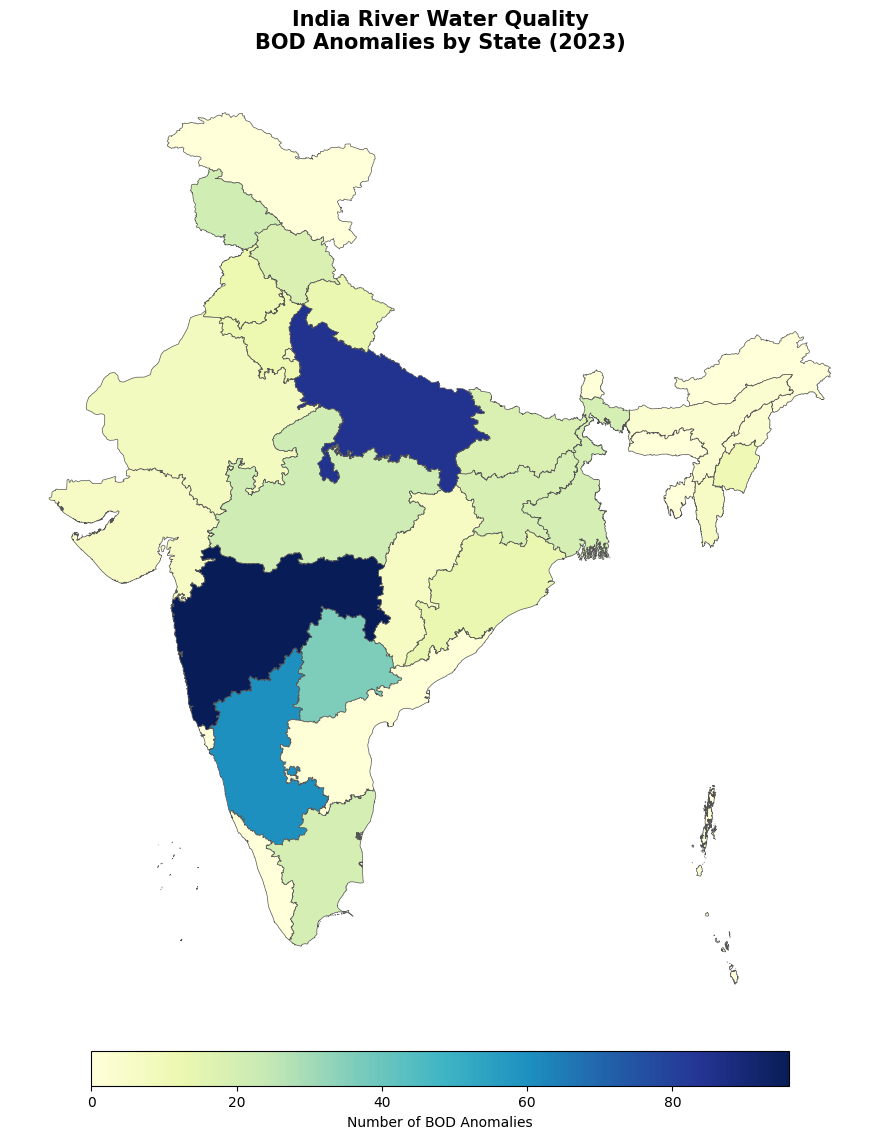

Map saved as image!


In [107]:
#Load & Merge Shapefile

india_merged = india.merge(state_anomalies, on = 'STNAME', how= 'left')

india_merged['BOD_Anomaly_Count']= india_merged['BOD_Anomaly_Count'].fillna(0)


#Ploting the Map
fig , ax = plt.subplots(1,1, figsize=(15,15))

india_merged.plot(
  column = 'BOD_Anomaly_Count',
  cmap='YlGnBu',
  linewidth= 0.5,
  ax= ax,
  edgecolor='#555555',
  legend=True,
  legend_kwds={'label': 'Number of BOD Anomalies', 
               'orientation': 'horizontal',
               'shrink': 0.6,
               'pad': 0.02}
,
missing_kwds={'color': '#d3d3d3', 'label': 'No Data'}  # grey for missing states
)

ax.set_title('India River Water Quality\nBOD Anomalies by State (2023)',
             fontsize=15, fontweight='bold', pad=15)

ax.set_facecolor('#e8f4f8')   # light blue background = water feel
fig.patch.set_facecolor('#ffffff')

ax.axis('off')

plt.savefig('india_water_quality_map.png', dpi=300, bbox_inches='tight')
plt.show()
print('Map saved as image!')
